# Práctica 2 — Determinación de tipos de estrellas

Matias Djukic           100504112@alumnos.uc3m.es
José María Duro Agea    100522306@alumnos.uc3m.es

## 1. Carga y preprocesamiento de datos

En este apartado se cargan los datos, se realiza una exploración inicial y se codifican de forma ordinal las variables categóricas (`Color` y `Spectral_Class`), respetando el orden físico subyacente de cada una.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

SEED = 100504112

np.random.seed(SEED)

### 1.1 Carga del conjunto de datos

In [29]:
df = pd.read_csv("stars_data.csv")
print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (240, 6)


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
dtypes: float64(3), int64(1), str(2)
memory usage: 11.4 KB


In [31]:
df.describe()

,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


In [32]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print()
print("Valores únicos — Color:")
print(sorted(df["Color"].unique()))
print()
print("Valores únicos — Spectral_Class:")
print(sorted(df["Spectral_Class"].unique()))

Valores nulos por columna:
Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64

Valores únicos — Color:
['Blue', 'Blue White', 'Blue white', 'Blue-White', 'Blue-white', 'Orange', 'Orange-Red', 'Pale yellow orange', 'Red', 'White', 'White-Yellow', 'Whitish', 'Yellowish', 'Yellowish White', 'white', 'yellow-white', 'yellowish']

Valores únicos — Spectral_Class:
['A', 'B', 'F', 'G', 'K', 'M', 'O']


### 1.2 Codificación ordinal de variables categóricas

Se opta por una codificación **ordinal** en lugar de *one-hot* porque ambas variables tienen un orden físico bien establecido:

- **`Spectral_Class`**: la secuencia O → B → A → F → G → K → M va de estrellas más calientes a más frías. Se asignan enteros de 0 (O) a 6 (M).
- **`Color`**: el color del espectro estelar está directamente relacionado con la temperatura de la estrella y, por tanto, con la energía emitida. El orden va de mayor a menor energía: azul → azul-blanco → blanco → amarillo-blanco → amarillo → naranja → rojo.

Una codificación arbitraria (e.g. one-hot o label encoding sin orden) introduciría distancias euclídeas sin sentido físico, lo que perjudicaría al clustering posterior.

In [33]:
# Normalización de cadenas para evitar inconsistencias (espacios, mayúsculas)
df["Color"] = df["Color"].str.strip().str.lower()
df["Spectral_Class"] = df["Spectral_Class"].str.strip().str.upper()

# Orden físico de Color (mayor a menor temperatura/energía)
color_order = [
    "blue",
    "blue-white",
    "blue white",
    "white",
    "yellow-white",
    "yellow white",
    "pale yellow orange",
    "yellowish white",
    "yellowish",
    "white-yellow",
    "yellow",
    "orange",
    "orange-red",
    "red",
]

# Orden físico de Spectral_Class (mayor a menor temperatura)
spectral_order = ["O", "B", "A", "F", "G", "K", "M"]

enc_color = OrdinalEncoder(
    categories=[color_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

enc_spectral = OrdinalEncoder(
    categories=[spectral_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

df["Color_enc"] = enc_color.fit_transform(df[["Color"]]).astype(int)
df["Spectral_Class_enc"] = enc_spectral.fit_transform(df[["Spectral_Class"]]).astype(int)

print("Mapeo Color:")
for i, c in enumerate(color_order):
    subset = df[df["Color"] == c]
    if not subset.empty:
        print(f"  {i:2d}  {c}")

print()
print("Mapeo Spectral_Class:")
for i, s in enumerate(spectral_order):
    print(f"  {i}  {s}")

Mapeo Color:
   0  blue
   1  blue-white
   2  blue white
   3  white
   4  yellow-white
   6  pale yellow orange
   7  yellowish white
   8  yellowish
   9  white-yellow
  11  orange
  12  orange-red
  13  red

Mapeo Spectral_Class:
  0  O
  1  B
  2  A
  3  F
  4  G
  5  K
  6  M


In [34]:
unknown_color = (df["Color_enc"] == -1).sum()
unknown_spectral = (df["Spectral_Class_enc"] == -1).sum()

if unknown_color > 0:
    print(f"Colores no mapeados ({unknown_color}):")
    print(df.loc[df["Color_enc"] == -1, "Color"].unique())

if unknown_spectral > 0:
    print(f"Clases espectrales no mapeadas ({unknown_spectral}):")
    print(df.loc[df["Spectral_Class_enc"] == -1, "Spectral_Class"].unique())

if unknown_color == 0 and unknown_spectral == 0:
    print("Todas las categorías han sido mapeadas correctamente.")

Colores no mapeados (2):
<StringArray>
['whitish']
Length: 1, dtype: str


### 1.3 Construcción de la matriz de características y estandarización

Se construye la matriz de características combinando las variables numéricas originales con las dos variables categóricas ya codificadas. Antes de aplicar PCA, se estandarizan todas las variables para que ninguna domine por magnitud.

In [35]:
feature_cols = ["Temperature", "L", "R", "A_M", "Color_enc", "Spectral_Class_enc"]

X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.describe().round(4)

,Temperature,L,R,A_M,Color_enc,Spectral_Class_enc
count,240.0000,240.0000,240.0000,240.0000,240.0000,240.0000
mean,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000
std,1.0021,1.0021,1.0021,1.0021,1.0021,1.0021
min,-0.8978,-0.5986,-0.4595,-1.5511,-1.3320,-1.3771
25%,-0.7504,-0.5986,-0.4593,-1.0099,-0.9964,-0.9813
50%,-0.4953,-0.5986,-0.4581,0.3740,0.0105,-0.1897
75%,0.4782,0.5074,-0.3767,0.8863,1.0174,0.9978
max,3.0949,4.1452,3.3161,1.4916,1.0174,0.9978


### 1.4 Reducción de dimensionalidad mediante PCA

Se aplica PCA con 2 componentes principales. Se reporta la varianza explicada por cada componente y la acumulada para evaluar la calidad de la proyección.

In [36]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada — PC1: {var_exp[0]:.4f} ({var_exp[0]*100:.2f}%)")
print(f"Varianza explicada — PC2: {var_exp[1]:.4f} ({var_exp[1]*100:.2f}%)")
print(f"Varianza explicada acumulada: {var_exp.sum():.4f} ({var_exp.sum()*100:.2f}%)")

Varianza explicada — PC1: 0.5538 (55.38%)
Varianza explicada — PC2: 0.2968 (29.68%)
Varianza explicada acumulada: 0.8506 (85.06%)


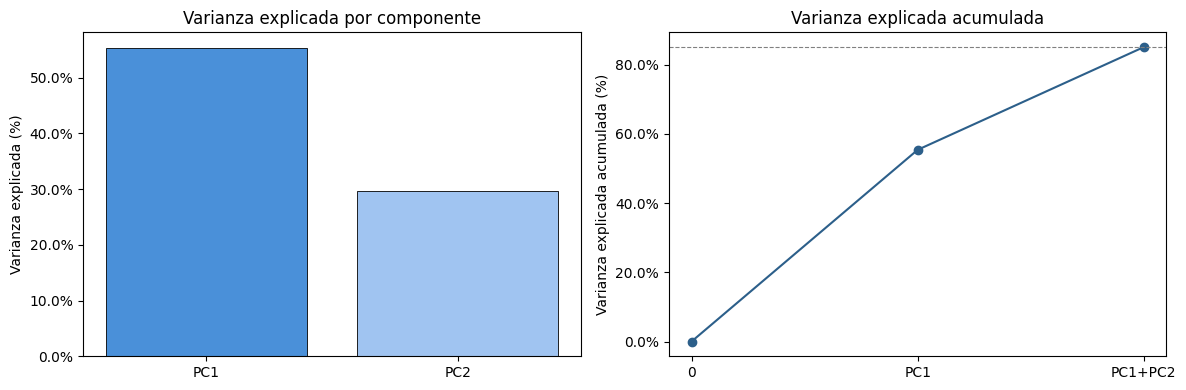

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Varianza explicada por componente
axes[0].bar(["PC1", "PC2"], var_exp * 100, color=["#4a90d9", "#a0c4f1"], edgecolor="black", linewidth=0.6)
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Varianza explicada por componente")
axes[0].yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f%%"))

# Varianza acumulada
axes[1].plot([0, 1, 2], [0, var_exp[0]*100, var_exp.sum()*100],
             marker="o", color="#2c5f8a", linewidth=1.5)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(["0", "PC1", "PC1+PC2"])
axes[1].set_ylabel("Varianza explicada acumulada (%)")
axes[1].set_title("Varianza explicada acumulada")
axes[1].yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f%%"))
axes[1].axhline(y=var_exp.sum()*100, linestyle="--", color="gray", linewidth=0.8)

plt.tight_layout()
plt.show()

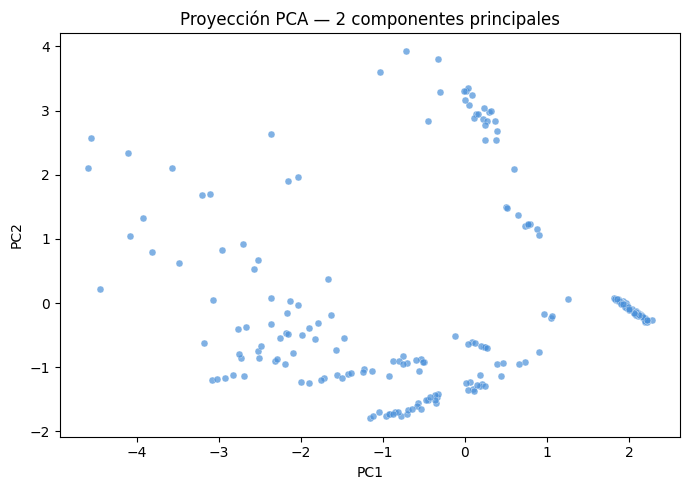

In [38]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_pca[:, 0], X_pca[:, 1], s=25, alpha=0.7, color="#4a90d9", edgecolors="white", linewidths=0.3)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Proyección PCA — 2 componentes principales")
plt.tight_layout()
plt.show()

In [39]:
# Cargas de cada variable en cada componente principal
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"]
).round(4)
print("Cargas (loadings) de las variables en las componentes principales:")
loadings

Cargas (loadings) de las variables en las componentes principales:


,PC1,PC2
Temperature,-0.4691,-0.2145
L,-0.3670,0.4078
R,-0.1710,0.6346
A_M,0.4025,-0.4005
Color_enc,0.4678,0.3498
Spectral_Class_enc,0.4851,0.3198


Los datos quedan proyectados en dos componentes principales. La varianza explicada acumulada indica en qué medida esta proyección conserva la estructura original del conjunto de datos. Con esta representación bidimensional se procederá a aplicar los algoritmos de clustering en los siguientes apartados.